[3 8 3 3 8 8 1 1 1 6 1 1 3 3 1 1 3 3 1 3]


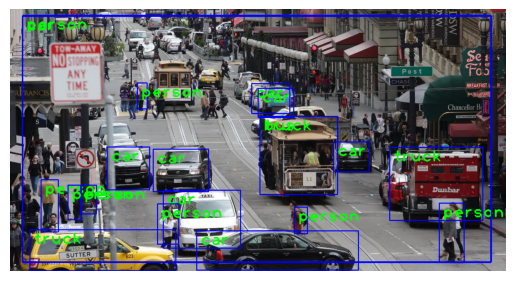

[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[ 1 65]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[1]
[ 1 65]
[1]
[ 1 65]
[1]
[ 1 65]
[ 1 65]
[1]
[1]
[1]
[ 1 65]
[ 1 65]
[ 1 65]
[1]
[ 1 65 72]
[ 1 72]
[ 1 72]
[ 1 65 72]
[ 1 72]
[ 1 72]
[ 1 72]
[ 1 72]
[ 1 65]
[ 1 72 65]
[ 1 72]
[ 1 72]
[ 1 72]
[ 1 72 65]
[ 1 72 65]
[ 1 72 65]
[ 1 72]
[1]
[1]
[ 1 72]
[ 1 72]
[ 1 65 72]
[ 1 65]
[ 1 65]
[1]
[1]
[1]
[ 1 72 65]
[ 1 72 65]
[ 1 72 65]
[ 1 72 65]
[ 1 72 65]
[ 1 72 65]
[ 1 65 72]
[ 1 65 72]
[ 1 65 72]
[ 1 65 72]
[ 1 65 72]
[ 1 65 72]
[ 1 72 65]
[ 1 72 65]
[ 1 65 72]
[ 1 65]
[ 1 65]
[ 1 65]


In [1]:
#my first model very basic and less accurate 
#made by Gaurav Shukla 


import cv2
import matplotlib.pyplot as plt

config_file = 'ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'
frozen_model = 'frozen_inference_graph.pb'

model = cv2.dnn_DetectionModel(frozen_model, config_file)

classLabels = []
file_name = 'labels.txt'
with open(file_name, 'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')

# print(classLabels)
# print(len(classLabels))

model.setInputSize(320, 320)
model.setInputScale(1.0 / 127.5)
model.setInputMean((127.5, 127.5, 127.5))
model.setInputSwapRB(True)

# Load and display the image
image = cv2.imread('sample_input.jpg')
if image is None:
    raise IOError("Image not found or unable to load.")

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert to RGB for display
ClassIndex, confidence, bbox = model.detect(image, confThreshold=0.5)
print(ClassIndex)

font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN
for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
    cv2.rectangle(image, boxes, (255, 0, 0), 2)
    cv2.putText(image, classLabels[ClassInd - 1], (boxes[0] + 10, boxes[1] + 40), font, fontScale=font_scale, color=(0, 255, 0), thickness=3)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide axes
plt.show()  # Show the image

# Video / webcam
cap = cv2.VideoCapture(0) #change camera source from here
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError('Cant open video')

while True:
    ret, frame = cap.read()
    if not ret:
        break  # Break the loop if there is an issue with the frame

    ClassIndex, confidence, bbox = model.detect(frame, confThreshold=0.5)
    print(ClassIndex)

    if len(ClassIndex) != 0:
        for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
            if ClassInd <= 80:
                cv2.rectangle(frame, boxes, (255, 0, 0), 2)
                cv2.putText(frame, classLabels[ClassInd - 1], (boxes[0] + 10, boxes[1] + 40), font, fontScale=font_scale, color=(0, 255, 0), thickness=3)

    cv2.imshow('Obj detection', frame)  # Show the frame with detections

    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


image 1/1 C:\Users\gaura\Desktop\object detection project\sample_input.jpg: 352x640 28 persons, 17 cars, 2 buss, 1 truck, 109.8ms
Speed: 2.2ms preprocess, 109.8ms inference, 7.9ms postprocess per image at shape (1, 3, 352, 640)


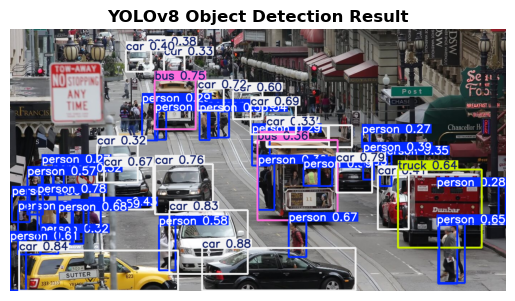

 Press 'Q' to quit the webcam window.

0: 480x640 1 person, 135.4ms
Speed: 2.0ms preprocess, 135.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 168.4ms
Speed: 2.6ms preprocess, 168.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 146.4ms
Speed: 3.8ms preprocess, 146.4ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 139.1ms
Speed: 1.9ms preprocess, 139.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 134.2ms
Speed: 1.5ms preprocess, 134.2ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 126.9ms
Speed: 1.3ms preprocess, 126.9ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 128.3ms
Speed: 1.7ms preprocess, 128.3ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 130.3ms
Speed: 1.8ms preprocess, 130.3ms inf

In [2]:


from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


model = YOLO("yolov8s.pt") 
image_path = "sample_input.jpg"  

results = model(image_path)

# Plot result using OpenCV + Matplotlib
result_image = results[0].plot()  
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8 Object Detection Result")
plt.show()


cap = cv2.VideoCapture(0)  
if not cap.isOpened():
    raise IOError(" Cannot open webcam")

print(" Press 'Q' to quit the webcam window.")

while True:
    ret, frame = cap.read()
    if not ret:
        print(" Frame not captured, exiting...")
        break

   
    results = model(frame)
    annotated_frame = results[0].plot()


    cv2.imshow("YOLOv8 Live Detection", annotated_frame)

    # Quit on 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Using device: cpu

image 1/1 C:\Users\gaura\Desktop\object detection project\sample_input.jpg: 704x1280 33 persons, 21 cars, 1 motorcycle, 2 buss, 1 train, 3 trucks, 3 traffic lights, 2 backpacks, 1 handbag, 4959.9ms
Speed: 11.3ms preprocess, 4959.9ms inference, 10.8ms postprocess per image at shape (1, 3, 704, 1280)


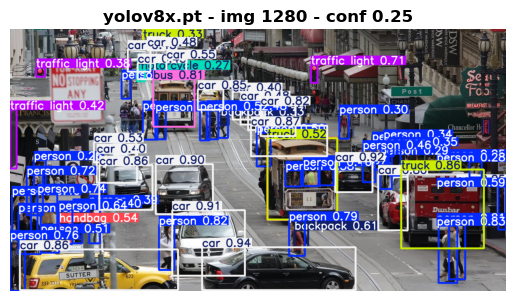

Press 'q' to quit.

0: 960x1280 1 person, 1 couch, 1 bed, 6562.7ms
Speed: 12.3ms preprocess, 6562.7ms inference, 2.2ms postprocess per image at shape (1, 3, 960, 1280)

0: 960x1280 2 persons, 1 umbrella, 6097.8ms
Speed: 15.7ms preprocess, 6097.8ms inference, 2.6ms postprocess per image at shape (1, 3, 960, 1280)

0: 960x1280 2 persons, 1 umbrella, 6078.0ms
Speed: 12.4ms preprocess, 6078.0ms inference, 2.2ms postprocess per image at shape (1, 3, 960, 1280)

0: 960x1280 2 persons, 1 umbrella, 1 bed, 6058.7ms
Speed: 12.0ms preprocess, 6058.7ms inference, 3.3ms postprocess per image at shape (1, 3, 960, 1280)

0: 960x1280 2 persons, 1 umbrella, 6890.8ms
Speed: 17.6ms preprocess, 6890.8ms inference, 2.3ms postprocess per image at shape (1, 3, 960, 1280)

0: 960x1280 1 person, 6084.1ms
Speed: 14.5ms preprocess, 6084.1ms inference, 3.0ms postprocess per image at shape (1, 3, 960, 1280)


In [4]:
# high_accuracy_yolo.py
from ultralytics import YOLO
import cv2
import time
import torch
import matplotlib.pyplot as plt


MODEL_NAME = "yolov8x.pt"      
IMAGE_SIZE = 1280              
CONF_THRESH = 0.25             # change to 0.3/0.4 for higher precision
IOU_THRESH = 0.45
USE_AUGMENT = True             )


device = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", device)


model = YOLO(MODEL_NAME)       


infer_kwargs = dict(
    imgsz=IMAGE_SIZE,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    augment=USE_AUGMENT,
    device=device
)

#Image test
image_path = "sample_input.jpg"
results = model(image_path, **infer_kwargs)   
annotated = results[0].plot()                
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"{MODEL_NAME} - img {IMAGE_SIZE} - conf {CONF_THRESH}")
plt.show()

# ---------- Webcam (real-time) ----------
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("Cannot open webcam")

prev_time = time.time()
print("Press 'q' to quit.")
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # run detection (frame can be passed directly)
        results = model(frame, **infer_kwargs)
        out_frame = results[0].plot()

        # compute & draw FPS
        cur_time = time.time()
        fps = 1.0 / (cur_time - prev_time + 1e-6)
        prev_time = cur_time
        cv2.putText(out_frame, f"FPS: {fps:.1f}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2.imshow("YOLOv8x High Accuracy", out_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

except KeyboardInterrupt:
    print("Stopped by user")

finally:
    cap.release()
    cv2.destroyAllWindows()


In [3]:
import matplotlib as m
import shutil, os

cache_dir = m.get_cachedir()
print("Deleting:", cache_dir)
shutil.rmtree(cache_dir, ignore_errors=True)
os.makedirs(cache_dir)
print("✅ Matplotlib cache cleared!")


Deleting: C:\Users\gaura\.matplotlib
✅ Matplotlib cache cleared!
